In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Introduction to AI_2025-26/Lab_2026/Lab2/diamonds.csv')

# **Storing only numerical value**


In [ ]:
numeric_df = data.select_dtypes(include='number')
numeric_df


,carat,depth,table,x,y,z,price
0,0.23,61.5,55.0,3.95,3.98,2.43,326
1,0.21,59.8,61.0,3.89,3.84,2.31,326
2,0.23,56.9,65.0,4.05,4.07,2.31,327
3,0.29,62.4,58.0,4.20,4.23,2.63,334
4,0.31,63.3,58.0,4.34,4.35,2.75,335
...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,2757
53936,0.72,63.1,55.0,5.69,5.75,3.61,2757
53937,0.70,62.8,60.0,5.66,5.68,3.56,2757
53938,0.86,61.0,58.0,6.15,6.12,3.74,2757


# **Display the five-number summary (Min, Q1, Median (Q2), Q3, Max)**

In [ ]:
# Summary statistics
summary_data = print(data.describe(include="all"))
summary_data

               carat    cut  color clarity         depth         table  \
count   53940.000000  53940  53940   53940  53940.000000  53940.000000   
unique           NaN      5      7       8           NaN           NaN   
top              NaN  Ideal      G     SI1           NaN           NaN   
freq             NaN  21551  11292   13065           NaN           NaN   
mean        0.797940    NaN    NaN     NaN     61.749405     57.457184   
std         0.474011    NaN    NaN     NaN      1.432621      2.234491   
min         0.200000    NaN    NaN     NaN     43.000000     43.000000   
25%         0.400000    NaN    NaN     NaN     61.000000     56.000000   
50%         0.700000    NaN    NaN     NaN     61.800000     57.000000   
75%         1.040000    NaN    NaN     NaN     62.500000     59.000000   
max         5.010000    NaN    NaN     NaN     79.000000     95.000000   

                   x             y             z         price  
count   53940.000000  53940.000000  53940.0000

# **Compute Q1, Q2, Q3, and IQR**

In [ ]:
# Quartiles

Q1 = data.select_dtypes(include='number').quantile(0.25)
Q2 = data.select_dtypes(include='number').quantile(0.50)
Q3 = data.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

print(f"Q1(First Quartile):{Q1}, Q2(Second Quartile): {Q2}, and Q3(Third quartile) : {Q3}")
print(f"Inter Quartile Range :{IQR}")

Q1(First Quartile):carat      0.40
depth     61.00
table     56.00
x          4.71
y          4.72
z          2.91
price    950.00
Name: 0.25, dtype: float64, Q2(Second Quartile): carat       0.70
depth      61.80
table      57.00
x           5.70
y           5.71
z           3.53
price    2401.00
Name: 0.5, dtype: float64, and Q3(Third quartile) : carat       1.04
depth      62.50
table      59.00
x           6.54
y           6.54
z           4.04
price    5324.25
Name: 0.75, dtype: float64
Inter Quartile Range :carat       0.64
depth       1.50
table       3.00
x           1.83
y           1.82
z           1.13
price    4374.25
dtype: float64


# **Display the five-number summary of the attribute `price`.**

In [ ]:
data['price'].describe()

,price
count,53940.000000
mean,3932.799722
std,3989.439738
min,326.000000
25%,950.000000
50%,2401.000000
75%,5324.250000
max,18823.000000


# **Find lower and upper bounds for `price`.**

In [ ]:
Q1 = data.select_dtypes(include='number').quantile(0.25)
Q2 = data.select_dtypes(include='number').quantile(0.50)
Q3 = data.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

print("Lower Bound:\n", Lower)
print("Upper Bound:\n", Upper)


Lower Bound:
 carat      -0.560
depth      58.750
table      51.500
x           1.965
y           1.990
z           1.215
price   -5611.375
dtype: float64
Upper Bound:
 carat        2.000
depth       64.750
table       63.500
x            9.285
y            9.270
z            5.735
price    11885.625
dtype: float64


In [ ]:
num = data.select_dtypes(include='number')

bounds = {}

for col in num.columns:
    Q1 = num[col].quantile(0.25)
    Q3 = num[col].quantile(0.75)
    IQR = Q3 - Q1

    Lower = Q1 - 1.5 * IQR
    Upper = Q3 + 1.5 * IQR

    bounds[col] = {"Lower": Lower, "Upper": Upper}


In [ ]:
bounds_df = pd.DataFrame(bounds)
bounds_df

,carat,depth,table,x,y,z,price
Lower,-0.56,58.75,51.5,1.965,1.99,1.215,-5611.375
Upper,2.00,64.75,63.5,9.285,9.27,5.735,11885.625


## **Adding Absolute value**

In [ ]:
Q1 = data.select_dtypes(include='number').quantile(0.25)
Q2 = data.select_dtypes(include='number').quantile(0.50)
Q3 = data.select_dtypes(include='number').quantile(0.75)

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

print("Lower Bound:", abs(Lower))
print("Upper Bound:", Upper)


Lower Bound: carat       0.560
depth      58.750
table      51.500
x           1.965
y           1.990
z           1.215
price    5611.375
dtype: float64
Upper Bound: carat        2.000
depth       64.750
table       63.500
x            9.285
y            9.270
z            5.735
price    11885.625
dtype: float64


In [ ]:
abs_num = data.select_dtypes(include = 'number')

bounds_abs = {}

for col in abs_num.columns:
  Q1 = abs_num[col].quantile(0.25)
  Q3 = abs_num[col].quantile(0.75)

  IQR = Q3 - Q1

  Lower = Q1 - 1.5 * IQR
  Upper = Q3 + 1.5 * IQR

  bounds_abs[col] = {"Lower": abs(Lower), "Upper": Upper}

bounds_df_abs = pd.DataFrame(bounds_abs)
bounds_df_abs

,carat,depth,table,x,y,z,price
Lower,0.56,58.75,51.5,1.965,1.99,1.215,5611.375
Upper,2.00,64.75,63.5,9.285,9.27,5.735,11885.625


# **Among price, carat, and depth, find the attribute having the highest IQR.**

In [ ]:
features = ['price', 'carat', 'depth']
iqr_values = {}

for col in features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    iqr_values[col] = Q3 - Q1

print(iqr_values)


{'price': np.float64(4374.25), 'carat': np.float64(0.64), 'depth': np.float64(1.5)}



# **3. Data Visualization Using Matplotlib**
* `Matplotlib` is a powerful plotting library for `Python` that enables the creation of static, animated, and interactive visualization.
* It is widely used for data visualization in data science and analytics.

In [ ]:
# Installing Library
!pip install matplotlib

In [ ]:
# Importing Library
import matplotlib.pyplot as plt

## **3.1 Line plots**

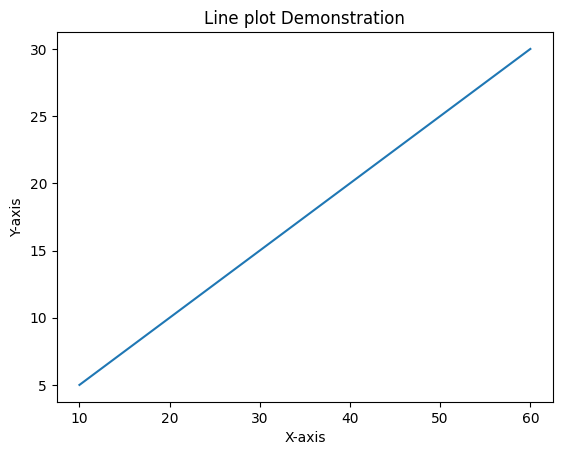

In [ ]:
x = [10,20,30,40,50,60]
y = [5,10,15,20,25,30]

# Creating line plot
plt.plot(x,y)
plt.title('Line plot Demonstration')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

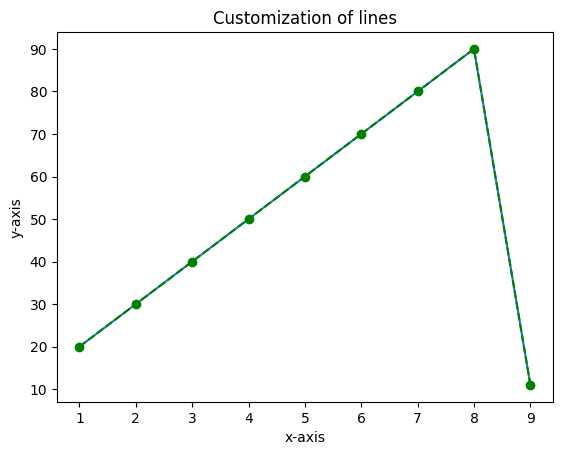

In [ ]:
# Creating line plot with customised lines
x1 = [1,2,3,4,5,6,7,8,9]
y1 = [20,30,40,50,60,70,80,90,11]

plt.plot(x1,y1)
plt.title("Customization of lines")
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.plot(x1,y1, color='green', linestyle='--', marker='o')

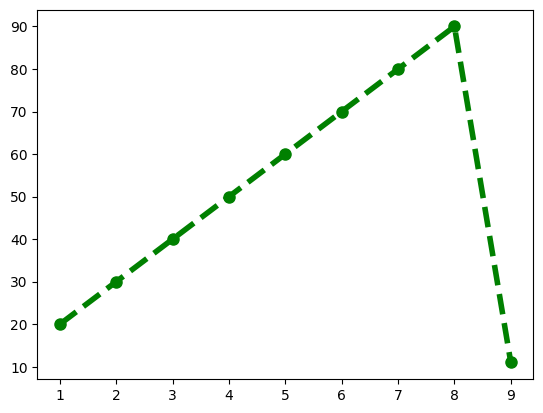

In [ ]:
# With costomization in line width
plt.plot(x1,y1, color='green', linestyle='--', marker='o', linewidth=4, markersize = 8)

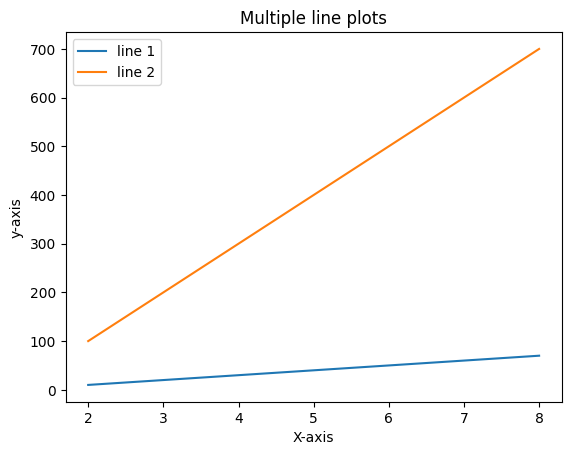

In [ ]:
# Multiple line plots
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]

plt.plot(x,y1, label = 'line 1')
plt.plot(x,y2, label = 'line 2')
plt.xlabel('X-axis')
plt.ylabel('y-axis')
plt.title('Multiple line plots')
plt.legend()
plt.show()

# Multiple sub plots

Text(0, 0.5, 'Y-axis')

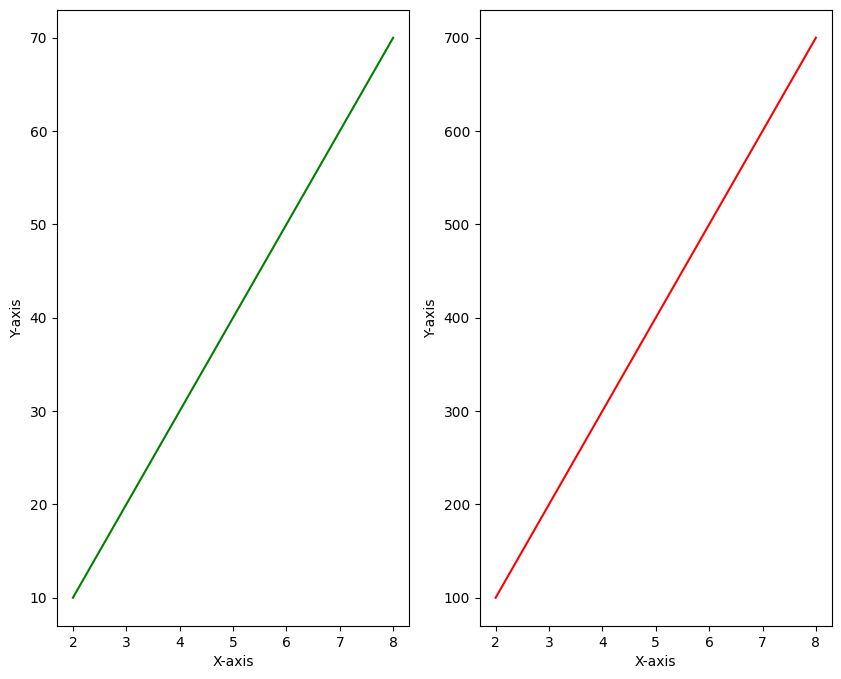

In [ ]:
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]

plt.figure(figsize = (10,8))

plt.subplot(1,2,1) # row, column, image position(index)
plt.plot(x,y1,label='Line 1', color='green')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.subplot(1,2,2) #row=1, columns=2
plt.plot(x,y2,label='Line 2', color='red')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

Text(0, 0.5, 'Y-axis')

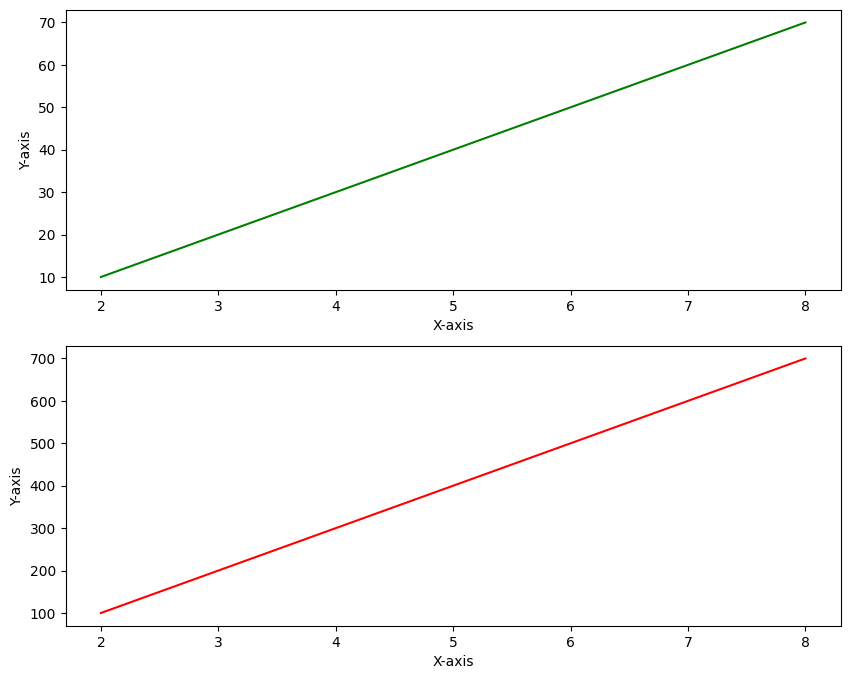

In [ ]:
# Displaying on different rows
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]

plt.figure(figsize = (10,8))

plt.subplot(2,1,1)
plt.plot(x,y1,label='Line 1', color='green')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.subplot(2,1,2) #row=1, columns=2
plt.plot(x,y2,label='Line 2', color='red')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

Text(0, 0.5, 'Y-axis')

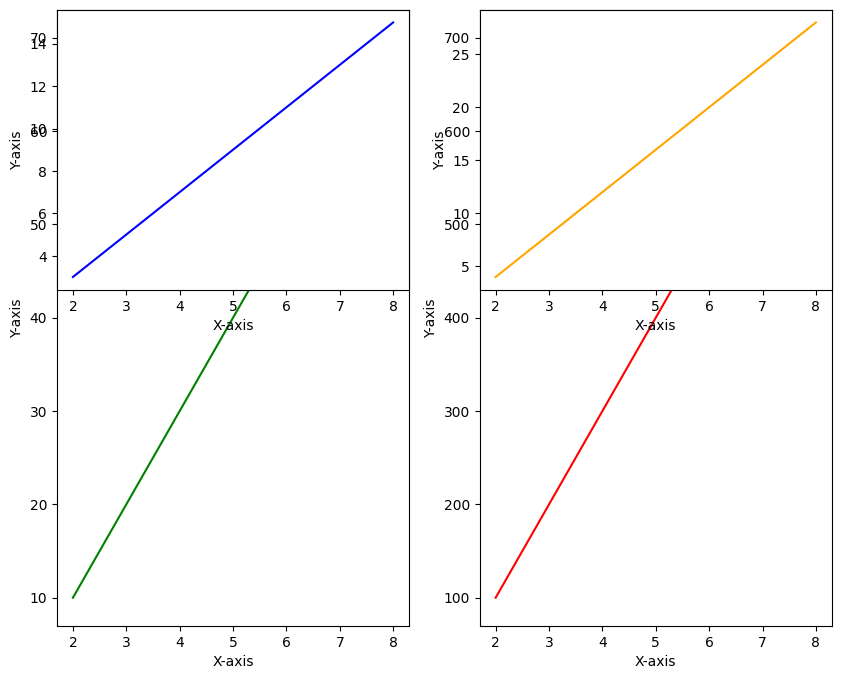

In [ ]:
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]
y3 = [3,5,7,9,11,13,15]
y4 = [4,8,12,16,20,24,28]

plt.figure(figsize = (10,8))

plt.subplot(1,2,1) # row, column, image position
plt.plot(x,y1,label='Line 1', color='green')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.subplot(1,2,2) #row=1, columns=2
plt.plot(x,y2,label='Line 2', color='red')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.subplot(2,2,1) # row, column, image position
plt.plot(x,y3,label='Line 3', color='blue')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.subplot(2,2,2) #row=1, columns=2
plt.plot(x,y4,label='Line 4', color='orange')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

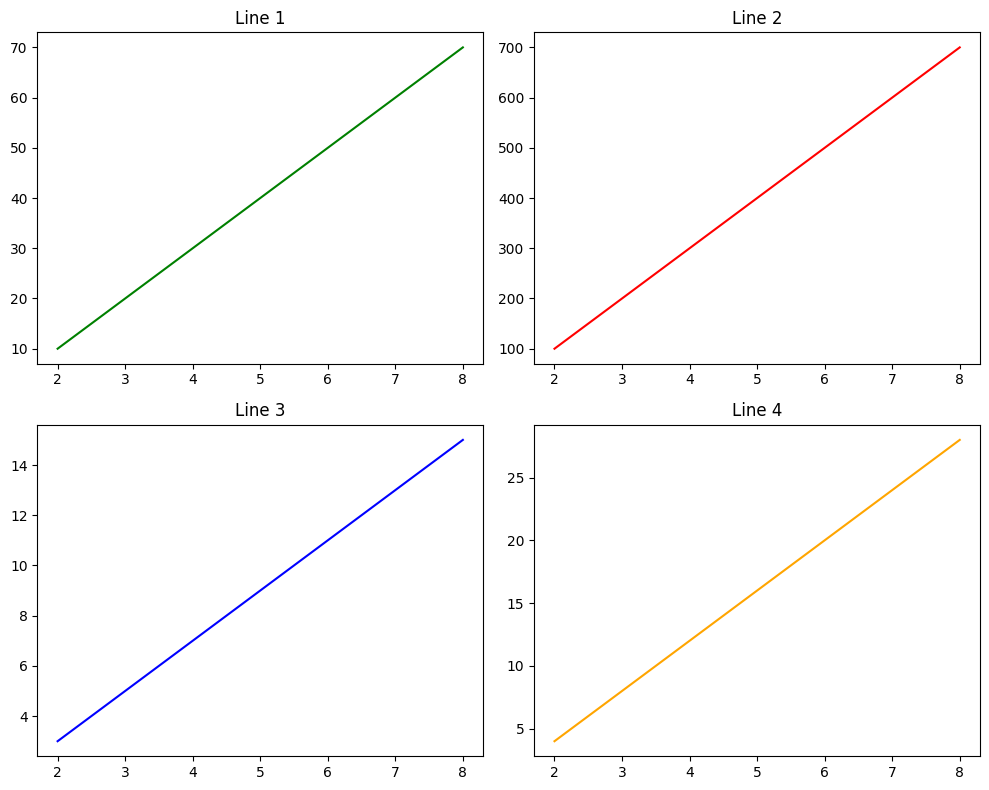

In [ ]:
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]
y3 = [3,5,7,9,11,13,15]
y4 = [4,8,12,16,20,24,28]

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot(x, y1, label='Line 1', color='green')
plt.title("Line 1")

plt.subplot(2,2,2)
plt.plot(x, y2, label='Line 2', color='red')
plt.title("Line 2")

plt.subplot(2,2,3)
plt.plot(x, y3, label='Line 3', color='blue')
plt.title("Line 3")

plt.subplot(2,2,4)
plt.plot(x, y4, label='Line 4', color='orange')
plt.title("Line 4")

plt.tight_layout()
plt.show()


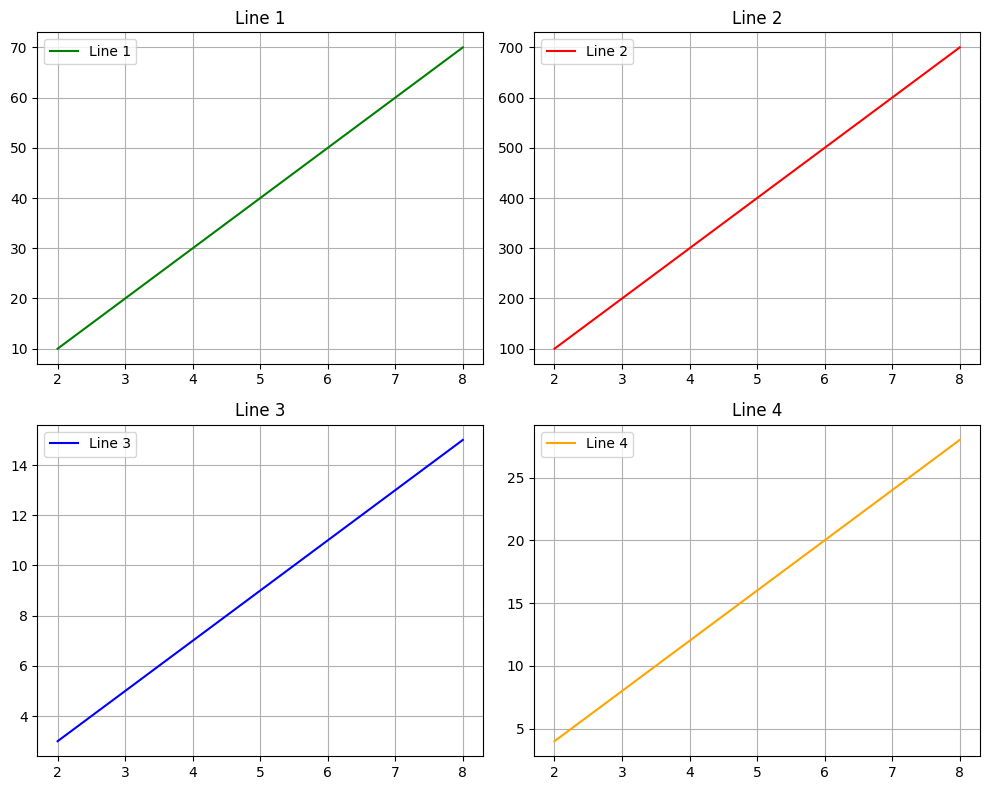

In [ ]:
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]
y3 = [3,5,7,9,11,13,15]
y4 = [4,8,12,16,20,24,28]

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot(x, y1, label='Line 1', color='green')
plt.title("Line 1")
plt.grid(True)
plt.legend()

plt.subplot(2,2,2)
plt.plot(x, y2, label='Line 2', color='red')
plt.title("Line 2")
plt.grid(True)
plt.legend()

plt.subplot(2,2,3)
plt.plot(x, y3, label='Line 3', color='blue')
plt.title("Line 3")
plt.grid(True)
plt.legend()

plt.subplot(2,2,4)
plt.plot(x, y4, label='Line 4', color='orange')
plt.title("Line 4")
plt.tight_layout()
plt.grid(True)
plt.legend()

plt.show()


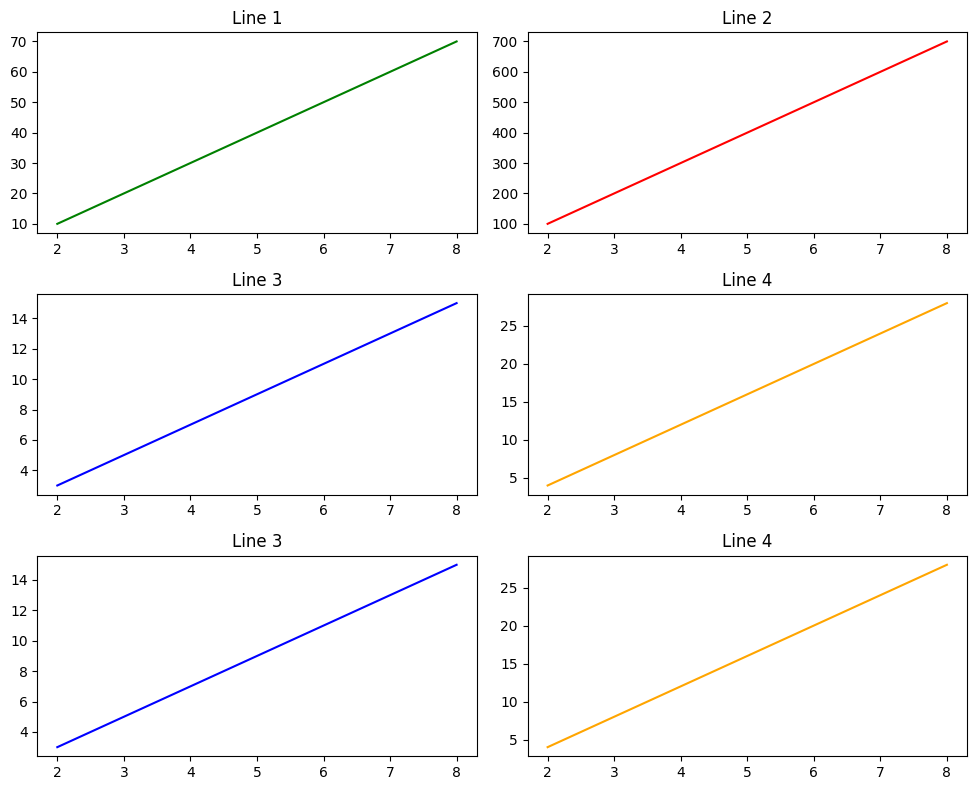

In [ ]:
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]
y3 = [3,5,7,9,11,13,15]
y4 = [4,8,12,16,20,24,28]

plt.figure(figsize=(10,8))

plt.subplot(3,2,1)
plt.plot(x, y1, label='Line 1', color='green')
plt.title("Line 1")

plt.subplot(3,2,2)
plt.plot(x, y2, label='Line 2', color='red')
plt.title("Line 2")

plt.subplot(3,2,3)
plt.plot(x, y3, label='Line 3', color='blue')
plt.title("Line 3")

plt.subplot(3,2,4)
plt.plot(x, y4, label='Line 4', color='orange')
plt.title("Line 4")

plt.subplot(3,2,5)
plt.plot(x, y3, label='Line 3', color='blue')
plt.title("Line 3")

plt.subplot(3,2,6)
plt.plot(x, y4, label='Line 4', color='orange')
plt.title("Line 4")

plt.tight_layout()
plt.show()


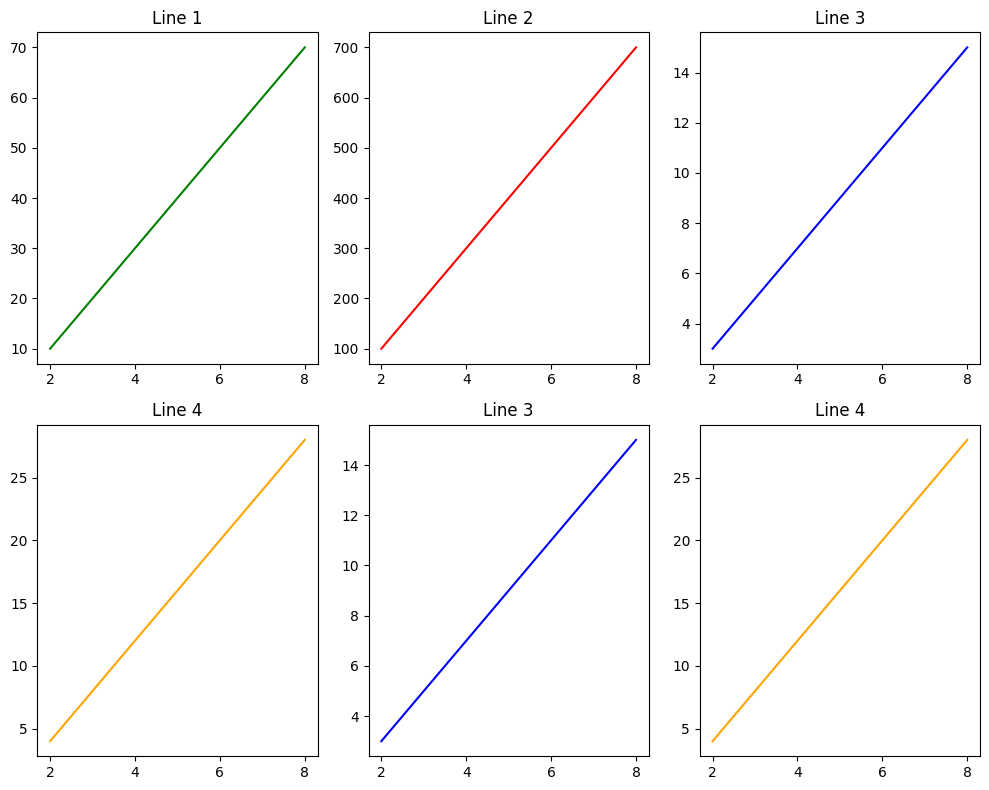

In [ ]:
x = [2,3,4,5,6,7,8]
y1 = [10,20,30,40,50,60,70]
y2 = [100,200,300,400,500,600,700]
y3 = [3,5,7,9,11,13,15]
y4 = [4,8,12,16,20,24,28]

plt.figure(figsize=(10,8))

plt.subplot(2,3,1)
plt.plot(x, y1, label='Line 1', color='green')
plt.title("Line 1")

plt.subplot(2,3,2)
plt.plot(x, y2, label='Line 2', color='red')
plt.title("Line 2")

plt.subplot(2,3,3)
plt.plot(x, y3, label='Line 3', color='blue')
plt.title("Line 3")

plt.subplot(2,3,4)
plt.plot(x, y4, label='Line 4', color='orange')
plt.title("Line 4")

plt.subplot(2,3,5)
plt.plot(x, y3, label='Line 3', color='blue')
plt.title("Line 3")

plt.subplot(2,3,6)
plt.plot(x, y4, label='Line 4', color='orange')
plt.title("Line 4")

plt.tight_layout()
plt.show()


## **3.2 Bar plots**

<BarContainer object of 5 artists>

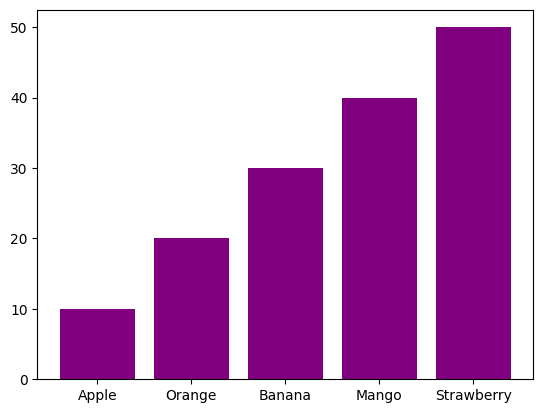

In [ ]:
# Bar plots
fruits = ['Apple', 'Orange', 'Banana', 'Mango', 'Strawberry']
quantity = [10, 20, 30, 40, 50]

plt.bar(fruits, quantity, color = 'purple')

## **GroupBy**

In [ ]:
sales_df = pd.read_csv('/content/drive/MyDrive/Introduction to AI_2025-26/Lab_2026/Lab1/sales_data.csv')
sales_df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [ ]:
numeric_df1 = sales_df.select_dtypes(include='number')
numeric_df1

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26,2013,19,8,45,120,590,360,950
1,26,2015,19,8,45,120,590,360,950
2,23,2014,49,23,45,120,1366,1035,2401
3,23,2016,49,20,45,120,1188,900,2088
4,15,2014,47,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...
113031,12,2016,41,3,24,64,112,72,184
113032,2,2014,18,22,24,64,655,528,1183
113033,2,2016,18,22,24,64,655,528,1183
113034,4,2014,37,24,24,64,684,576,1260


                  Unit_Cost  Unit_Price    Profit
Product_Category                                 
Accessories          443530     1185400   8862377
Bikes              29400230    49395368  20519276
Clothing             370352      617580   2839447


[]

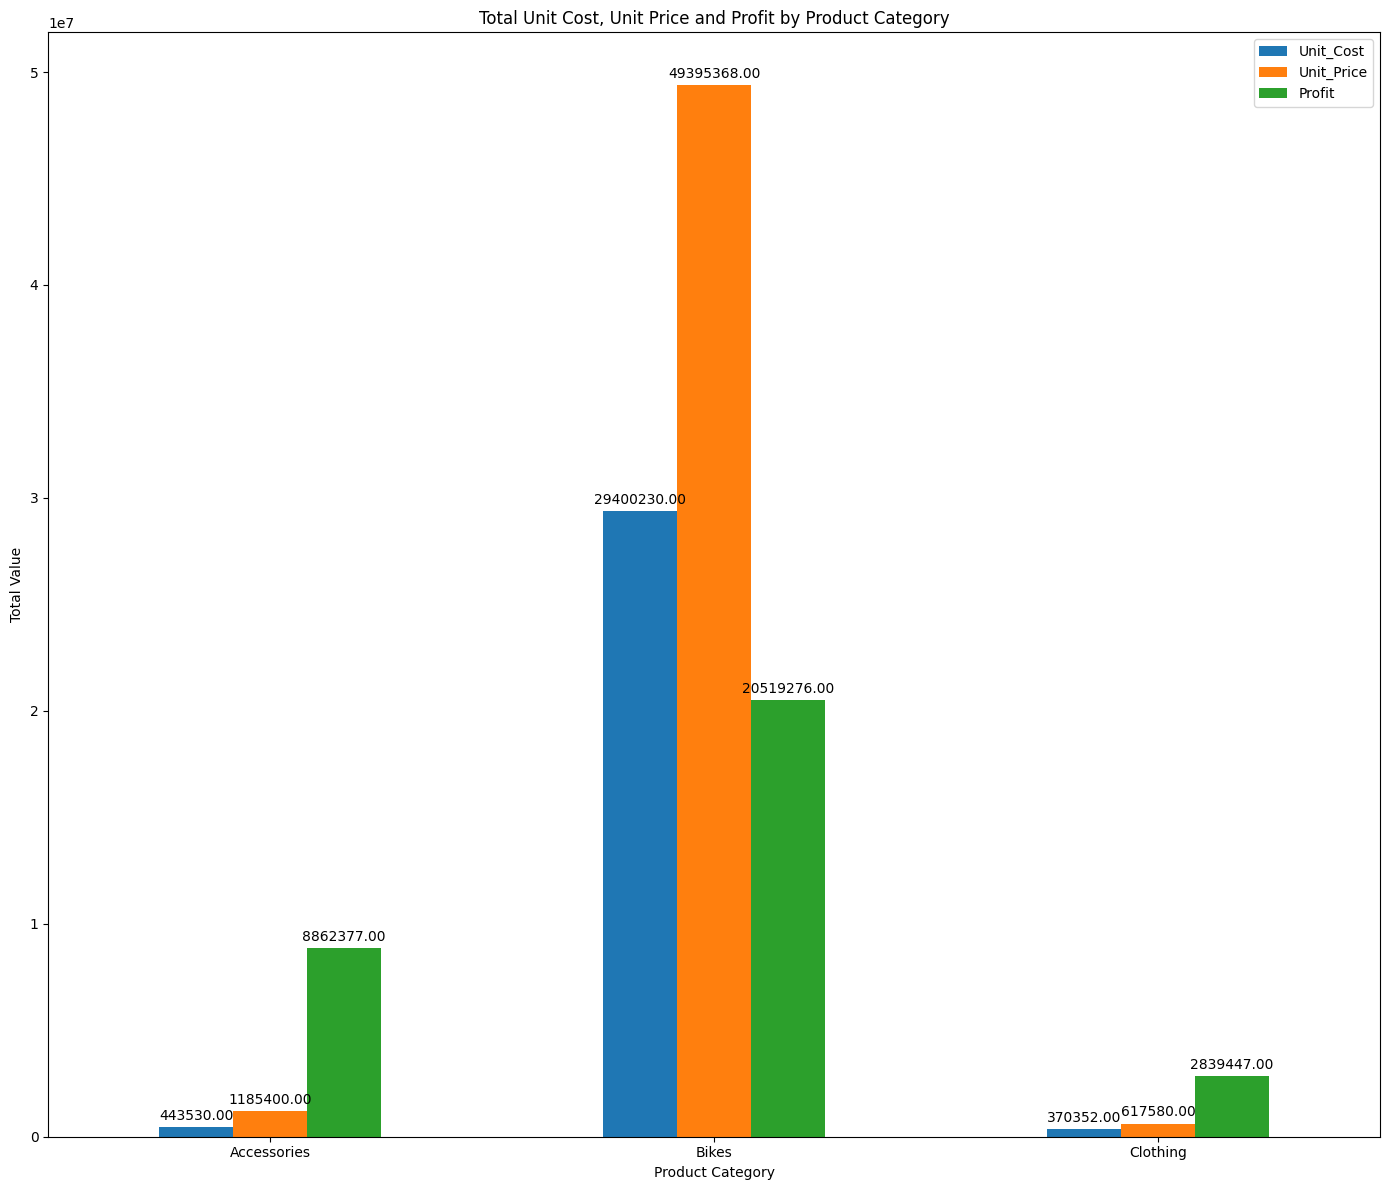

In [ ]:
# Plot profit by Category
total_profit = sales_df.groupby('Product_Category')[['Unit_Cost', 'Unit_Price', 'Profit']].sum()
print(total_profit)


ax = total_profit.plot(kind='bar', figsize=(14,12))
plt.title('Total Unit Cost, Unit Price and Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Value')
plt.xticks(rotation=0)

for container in ax.containers: # ax.containers refers to a list of container objects that hold groups of artists (graphical elements) created by certain plotting functions
    ax.bar_label(container, fmt='%.2f', padding=3, rotation = 0)

plt.tight_layout()
plt.plot()


### **3.3 Histogram of all numeric features**
* Histograms are used to represent the distribution of a dataset.
They divide the data into bins and count the number of data points in each bin.

Text(0, 0.5, 'Frequency')

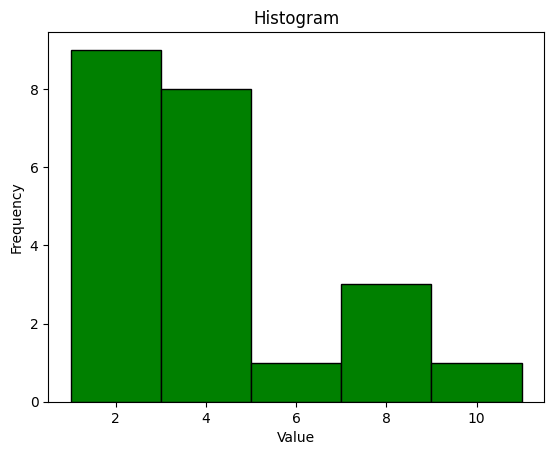

In [ ]:
a = [1,1,1,1,2,2,2,2,2,3,3,4,4,4,4,4,4,5,11,7,7,7]

plt.hist(a, bins=5, color='green', edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')


### **A Kernel Density Estimation (KDE) plot is a non-parametric way to estimate and visualize the probability density function (PDF) of a continuous random variable. It provides a smooth alternative to a histogram, making distributional shape easier to interpret.**

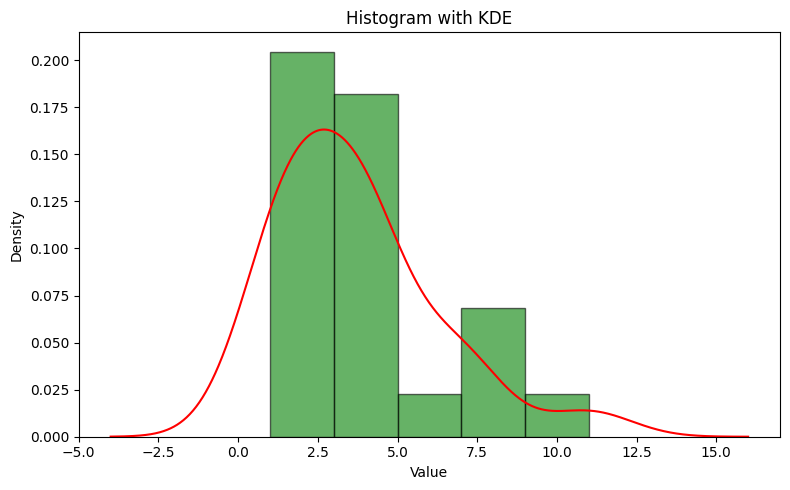

In [ ]:
a = [1,1,1,1,2,2,2,2,2,3,3,4,4,4,4,4,4,5,11,7,7,7]

plt.figure(figsize=(8,5))

# Histogram (normalized)
plt.hist(a, bins=5, density=True, color='green', edgecolor='black', alpha=0.6)

# KDE curve
pd.Series(a).plot(kind='kde', color='red')

plt.title('Histogram with KDE')
plt.xlabel('Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


## **KDE Plot with Mean and Median Overlay**

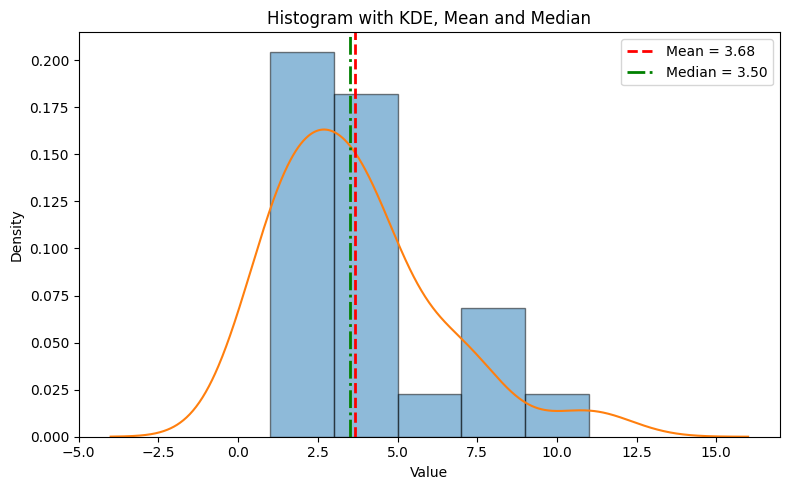

In [ ]:
a = [1,1,1,1,2,2,2,2,2,3,3,4,4,4,4,4,4,5,11,7,7,7]

mean_val = np.mean(a)
median_val = np.median(a)

plt.figure(figsize=(8,5))

# Histogram
plt.hist(a, bins=5, density=True, edgecolor='black', alpha=0.5)

# KDE curve
pd.Series(a).plot(kind='kde')

# Mean & Median lines
plt.axvline(mean_val, linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}", color = "red") # plt.axvline is a Matplotlib utility function used to draw a vertical reference line across a plot
plt.axvline(median_val, linestyle='-.', linewidth=2, label=f"Median = {median_val:.2f}", color = "green")

plt.title('Histogram with KDE, Mean and Median')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## **KDE Plot with Mean, Median, and ±2.7σ Limits**


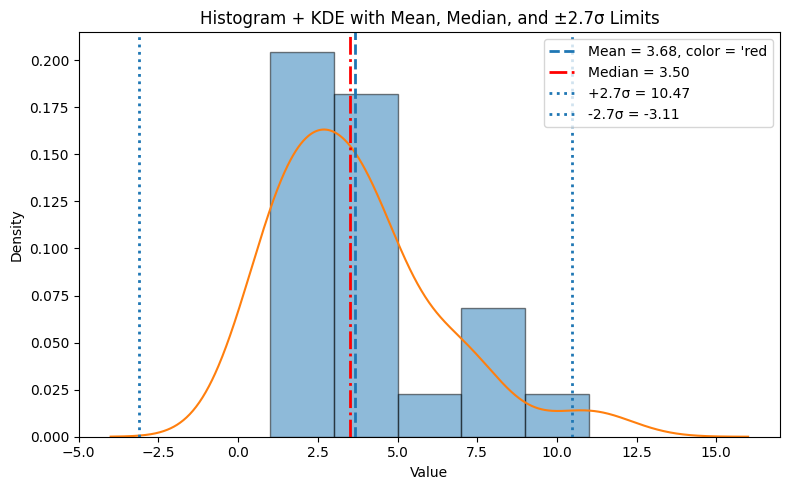

In [ ]:
a = [1,1,1,1,2,2,2,2,2,3,3,4,4,4,4,4,4,5,11,7,7,7]

mu = np.mean(a)
sigma = np.std(a, ddof=1)   # sample std deviation

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(8,5))

plt.hist(a, bins=5, density=True, edgecolor='black', alpha=0.5)
pd.Series(a).plot(kind='kde')

plt.axvline(mu, linestyle='--', linewidth=2, label=f"Mean = {mu:.2f}, color = 'red")
plt.axvline(np.median(a), linestyle='-.', linewidth=2, label=f"Median = {np.median(a):.2f}", color = 'red')

plt.axvline(ucl, linestyle=':', linewidth=2, label=f"+2.7σ = {ucl:.2f}")
plt.axvline(lcl, linestyle=':', linewidth=2, label=f"-2.7σ = {lcl:.2f}")

plt.title('Histogram + KDE with Mean, Median, and ±2.7σ Limits')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

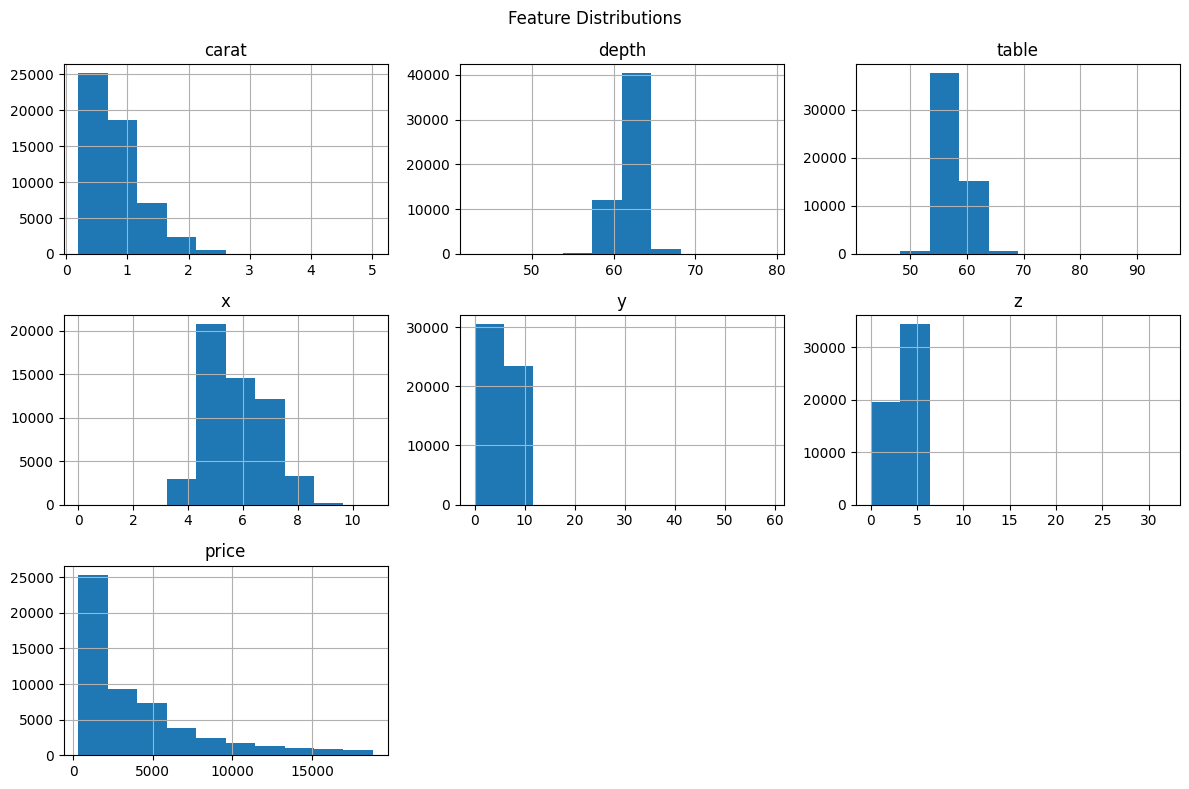

In [ ]:
numeric_df.hist(figsize=(12, 8))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

## **with KDE plot**

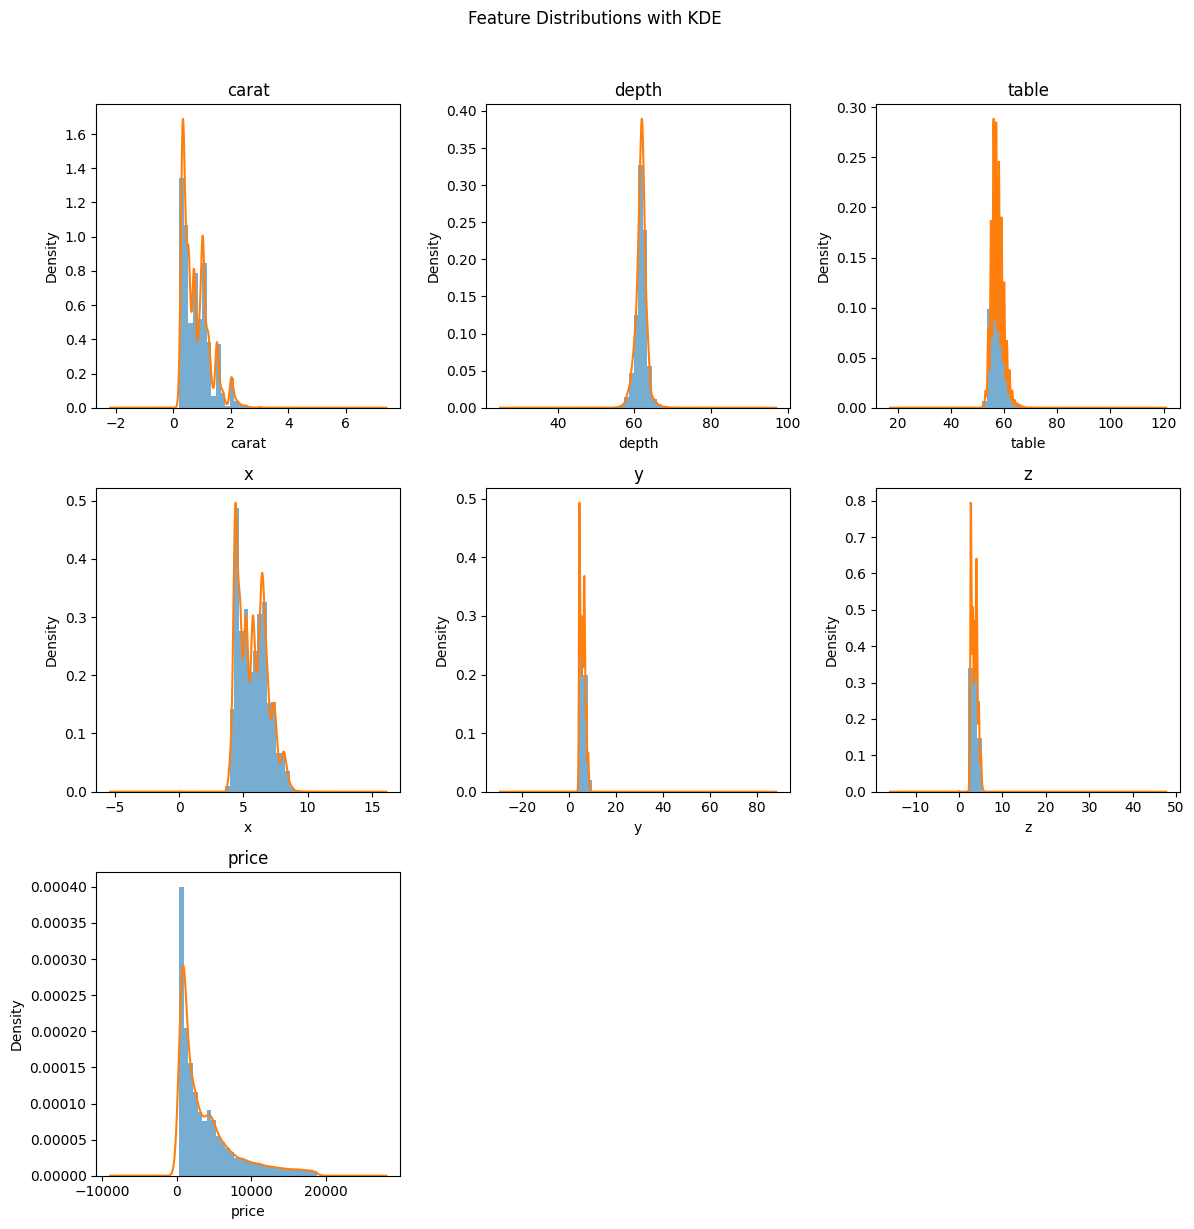

In [ ]:
numeric_cols = numeric_df.select_dtypes(include='number')
num_cols = len(numeric_cols.columns)
rows = (num_cols // 3) + 1 # how many rows of subplots are needed when you want to place

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(numeric_cols.columns, 1):
    plt.subplot(rows, 3, i)

    # Histogram
    plt.hist(numeric_cols[col].dropna(), bins=30, density=True, alpha=0.6)

    # KDE
    numeric_cols[col].dropna().plot(kind='kde')

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Density')

plt.suptitle("Feature Distributions with KDE", y=1.02)
plt.tight_layout()
plt.show()


## **Multi-Feature Distribution with Mean, Median, Mode & ±2.7σ**

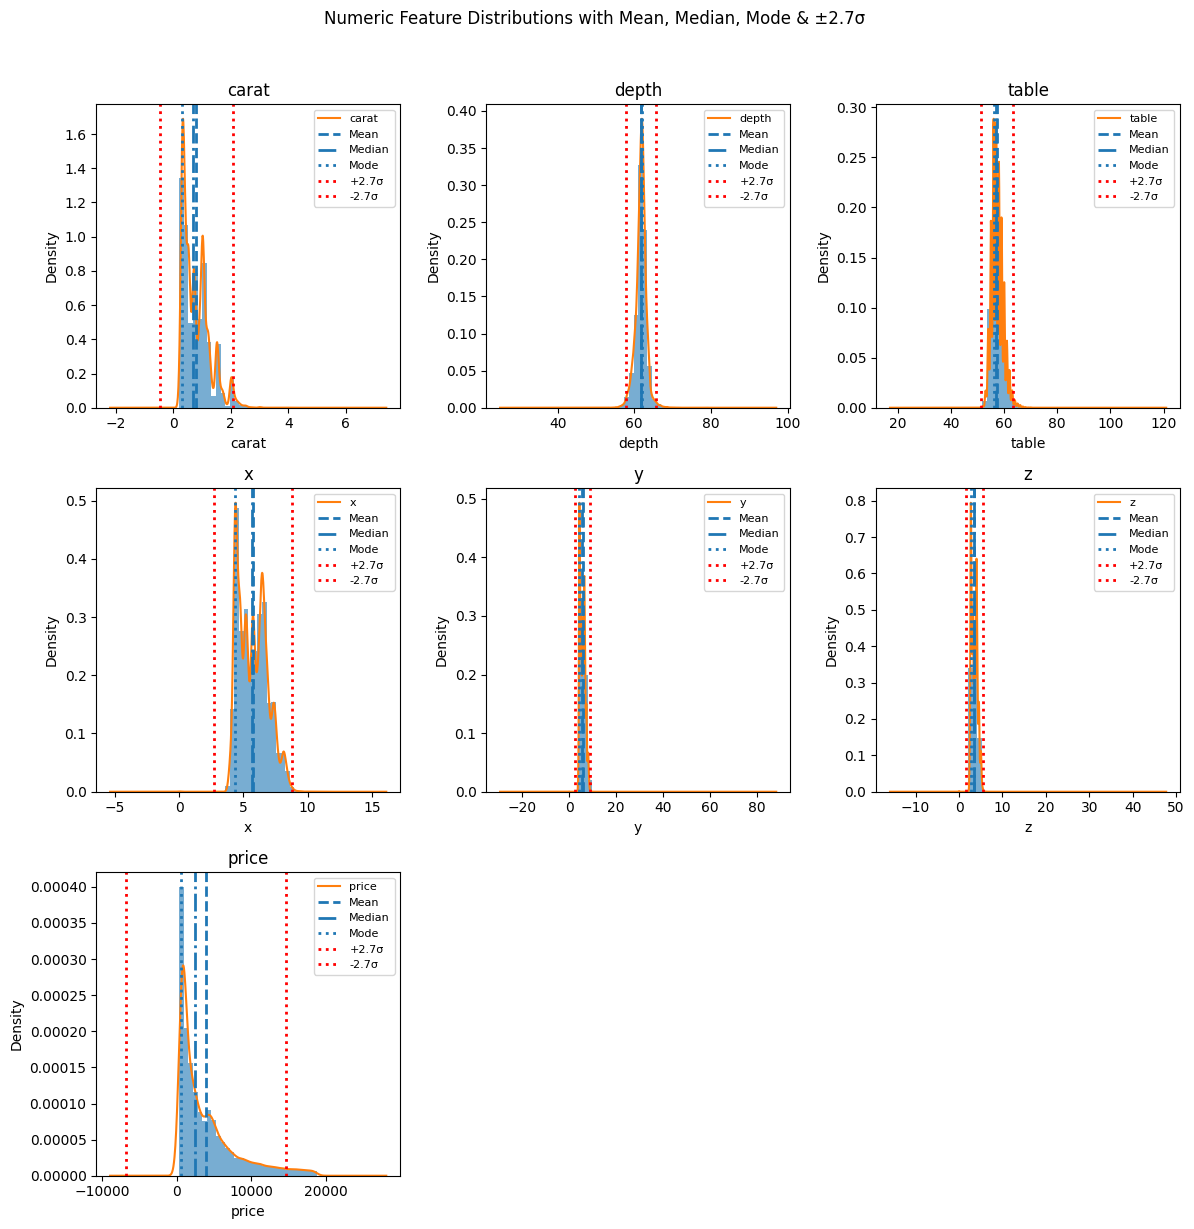

In [ ]:
numeric_cols = numeric_df.select_dtypes(include='number')

num_cols = len(numeric_cols.columns)
rows = (num_cols // 3) + 1

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(numeric_cols.columns, 1):
    data_col = numeric_cols[col].dropna()

    mu = data_col.mean()
    median = data_col.median()
    mode = data_col.mode().iloc[0] #.iloc[0] selects the first one from many modes
    sigma = data_col.std(ddof=1) # ddof : Delta Degrees of Freedom

    ucl = mu + 2.7 * sigma
    lcl = mu - 2.7 * sigma

    plt.subplot(rows, 3, i)

    plt.hist(data_col, bins=30, density=True, alpha=0.6)
    data_col.plot(kind='kde')

    plt.axvline(mu, linestyle='--', linewidth=2, label=f"Mean")
    plt.axvline(median, linestyle='-.', linewidth=2, label=f"Median")
    plt.axvline(mode, linestyle=':', linewidth=2, label=f"Mode")
    plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label="+2.7σ")
    plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label="-2.7σ")

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions with Mean, Median, Mode & ±2.7σ", y=1.02)
plt.tight_layout()
plt.show()

### **3.5. Boxplot (outlier detection)**

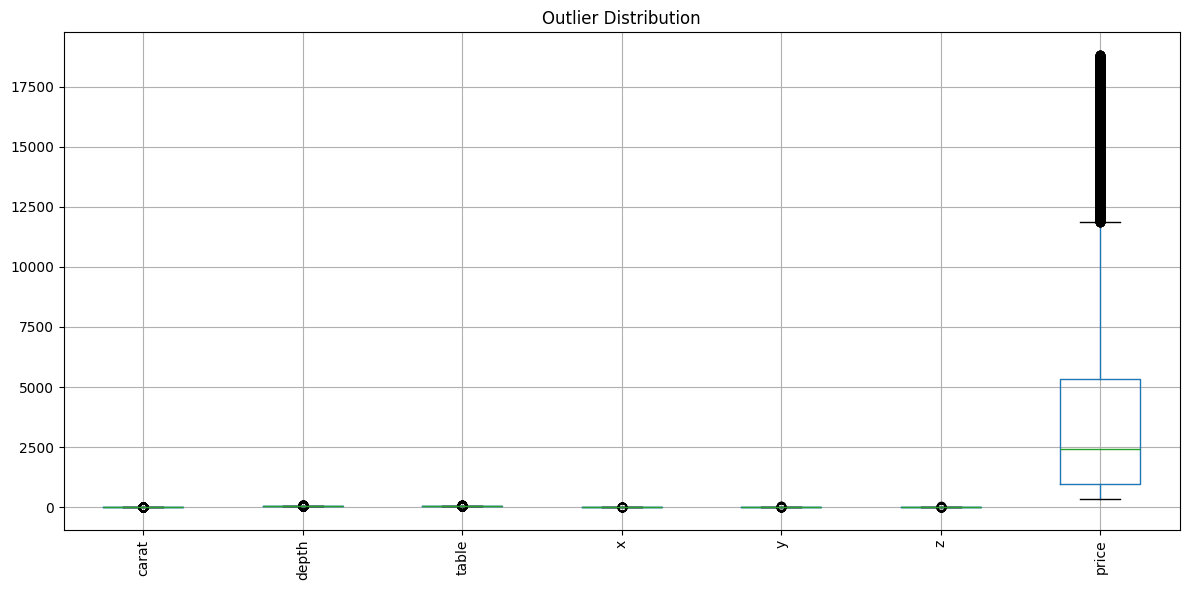

In [ ]:
plt.figure(figsize=(12, 6))
numeric_df.boxplot()
plt.title("Outlier Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# **Histogram + KDE and Boxplot for `depth`**

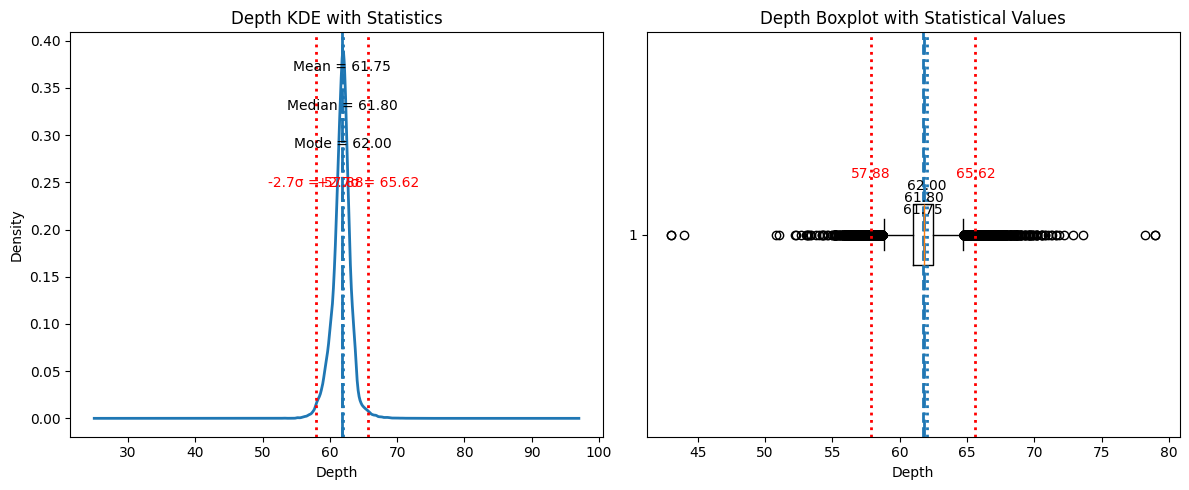

In [ ]:
d = numeric_df['depth'].dropna()

mu = d.mean()
median = d.median()
mode = d.mode().iloc[0]
sigma = d.std(ddof=1)

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(12,5))

# KDE Plot
plt.subplot(1,2,1)
d.plot(kind='kde', linewidth=2)

plt.axvline(mu, linestyle='--', linewidth=2)
plt.axvline(median, linestyle='-.', linewidth=2)
plt.axvline(mode, linestyle=':', linewidth=2)
plt.axvline(ucl, linestyle=':', linewidth=2, color='red')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red')

plt.text(mu, plt.ylim()[1]*0.9, f"Mean = {mu:.2f}", ha='center')
plt.text(median, plt.ylim()[1]*0.8, f"Median = {median:.2f}", ha='center')
plt.text(mode, plt.ylim()[1]*0.7, f"Mode = {mode:.2f}", ha='center')
plt.text(ucl, plt.ylim()[1]*0.6, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
plt.text(lcl, plt.ylim()[1]*0.6, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

plt.title("Depth KDE with Statistics")
plt.xlabel("Depth")
plt.ylabel("Density")

# Boxplot with numeric labels
plt.subplot(1,2,2)
plt.boxplot(d, vert=False)

plt.axvline(mu, linestyle='--', linewidth=2)
plt.axvline(median, linestyle='-.', linewidth=2)
plt.axvline(mode, linestyle=':', linewidth=2)
plt.axvline(ucl, linestyle=':', linewidth=2, color='red')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red')

# Numeric annotations on boxplot
ypos = 1.05
plt.text(mu, ypos, f"{mu:.2f}", ha='center')
plt.text(median, ypos+0.03, f"{median:.2f}", ha='center')
plt.text(mode, ypos+0.06, f"{mode:.2f}", ha='center')
plt.text(ucl, ypos+0.09, f"{ucl:.2f}", ha='center', color='red')
plt.text(lcl, ypos+0.09, f"{lcl:.2f}", ha='center', color='red')

plt.title("Depth Boxplot with Statistical Values")
plt.xlabel("Depth")

plt.tight_layout()
plt.show()


## **Skewed feature `price`**

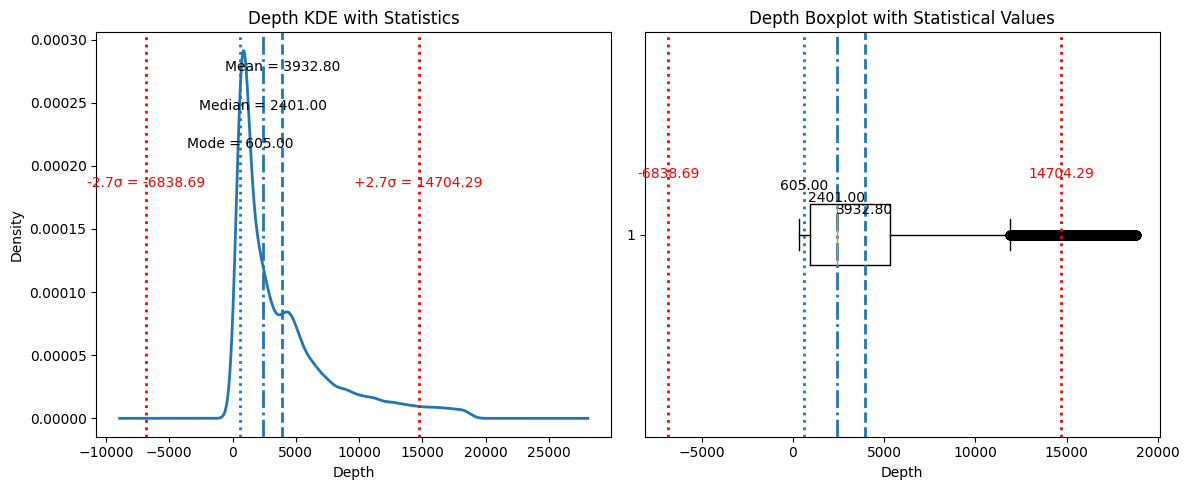

In [ ]:
d = numeric_df['price'].dropna()

mu = d.mean()
median = d.median()
mode = d.mode().iloc[0]
sigma = d.std(ddof=1)

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(12,5))

# KDE Plot
plt.subplot(1,2,1)
d.plot(kind='kde', linewidth=2)

plt.axvline(mu, linestyle='--', linewidth=2)
plt.axvline(median, linestyle='-.', linewidth=2)
plt.axvline(mode, linestyle=':', linewidth=2)
plt.axvline(ucl, linestyle=':', linewidth=2, color='red')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red')

plt.text(mu, plt.ylim()[1]*0.9, f"Mean = {mu:.2f}", ha='center')
plt.text(median, plt.ylim()[1]*0.8, f"Median = {median:.2f}", ha='center')
plt.text(mode, plt.ylim()[1]*0.7, f"Mode = {mode:.2f}", ha='center')
plt.text(ucl, plt.ylim()[1]*0.6, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
plt.text(lcl, plt.ylim()[1]*0.6, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

plt.title("Depth KDE with Statistics")
plt.xlabel("Depth")
plt.ylabel("Density")

# Boxplot with numeric labels
plt.subplot(1,2,2)
plt.boxplot(d, vert=False)

plt.axvline(mu, linestyle='--', linewidth=2)
plt.axvline(median, linestyle='-.', linewidth=2)
plt.axvline(mode, linestyle=':', linewidth=2)
plt.axvline(ucl, linestyle=':', linewidth=2, color='red')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red')

# Numeric annotations on boxplot
ypos = 1.05
plt.text(mu, ypos, f"{mu:.2f}", ha='center')
plt.text(median, ypos+0.03, f"{median:.2f}", ha='center')
plt.text(mode, ypos+0.06, f"{mode:.2f}", ha='center')
plt.text(ucl, ypos+0.09, f"{ucl:.2f}", ha='center', color='red')
plt.text(lcl, ypos+0.09, f"{lcl:.2f}", ha='center', color='red')

plt.title("Depth Boxplot with Statistical Values")
plt.xlabel("Depth")

plt.tight_layout()
plt.show()


### **3.6 Example Scatter Plot**

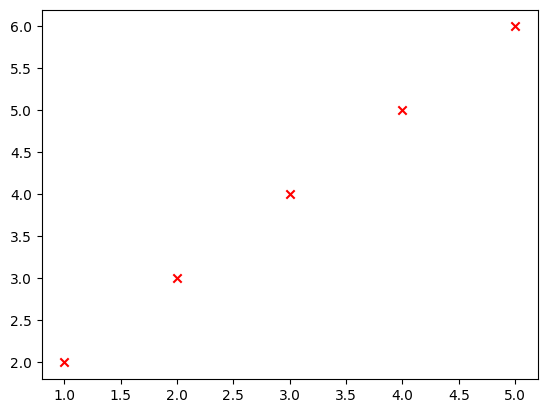

In [ ]:
## Creating a scatter plot
x=[1,2,3,4,5]
y=[2,3,4,5,6]

plt.scatter(x,y,color='red',marker='x')

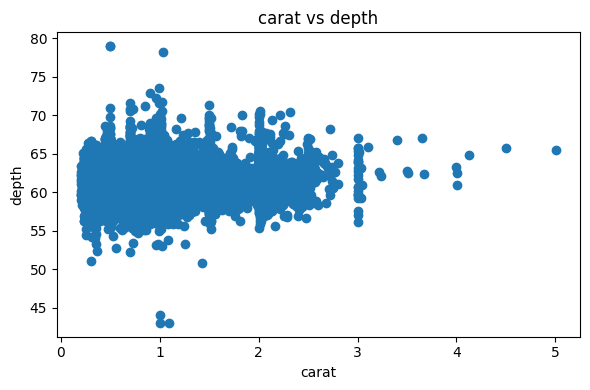

In [ ]:
if len(numeric_df.columns) >= 2:
    x = numeric_df.columns[0]
    y = numeric_df.columns[1]

    plt.figure(figsize=(6,4))
    plt.scatter(data[x], data[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()


## **Pie Chart**

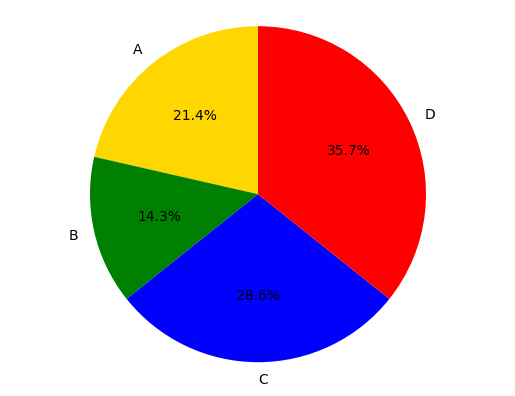

In [ ]:
## pie chart
labels=['A','B','C','D']
sizes=[30,20,40,50]
colors=['gold','green','blue','red']


plt.pie(sizes,labels=labels,colors=colors,autopct='%1.1f%%',startangle=90)
plt.axis('equal')
plt.show()

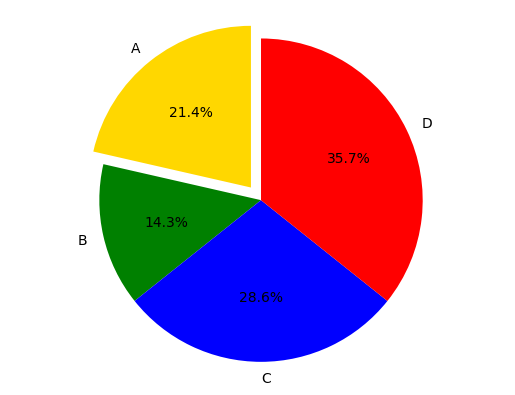

In [ ]:
## pipe chart
labels=['A','B','C','D']
sizes=[30,20,40,50]
colors=['gold','green','blue','red']
explode=(0.1,0,0,0)### Move out the first slide

plt.pie(sizes,explode=explode,labels=labels,colors=colors,autopct='%1.1f%%',startangle=90)
plt.axis('equal')
plt.show()

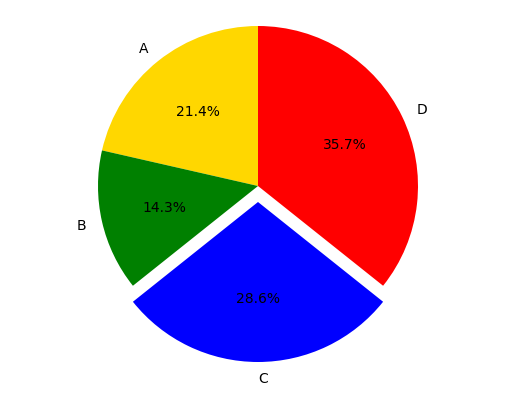

In [ ]:
## pipe chart
labels=['A','B','C','D']
sizes=[30,20,40,50]
colors=['gold','green','blue','red']
explode=(0,0,0.1,0)### Move out the first slide

plt.pie(sizes,explode=explode,labels=labels,colors=colors,autopct='%1.1f%%',startangle=90)
plt.axis('equal')
plt.show()

# **4. Data Visualization with Seaborn**
Seaborn is a Python visualization library based on Matplotlib that provides high-level interface for drawing attractive and informative statistical graphics. Seaborn helps in creating complex visualizations with just a few lines of code.


In [ ]:
# Installing library
!pip install seaborn

In [ ]:
# Importing library
import seaborn as sns

## **Basic plotting with Seaborn**

In [ ]:
# Downloading dataset from seaborn library
tips = sns.load_dataset('tips')
tips


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### **Creating Scatter Plot**

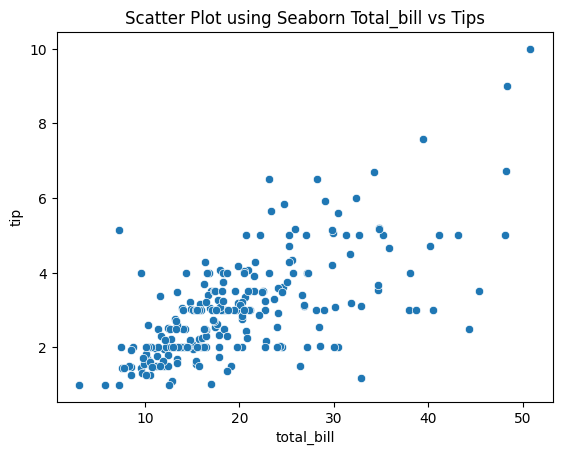

In [ ]:
import matplotlib.pyplot as plt

sns.scatterplot(x='total_bill', y='tip', data=tips)
plt.title('Scatter Plot using Seaborn Total_bill vs Tips')
plt.show()

### **Line PLot**

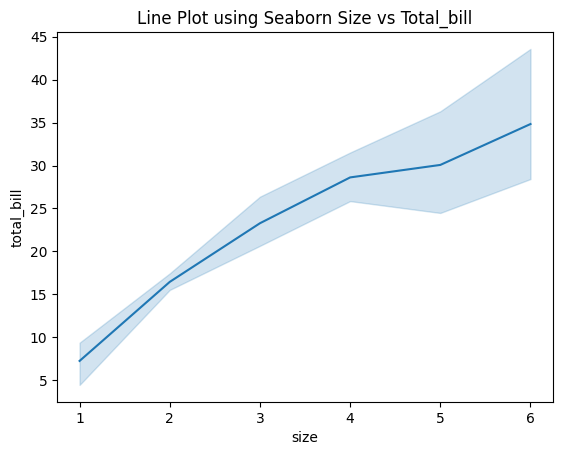

In [ ]:
sns.lineplot(x='size', y='total_bill', data=tips)
plt.title('Line Plot using Seaborn Size vs Total_bill')
plt.show()

### **Categorical Plots -- Bar plot**

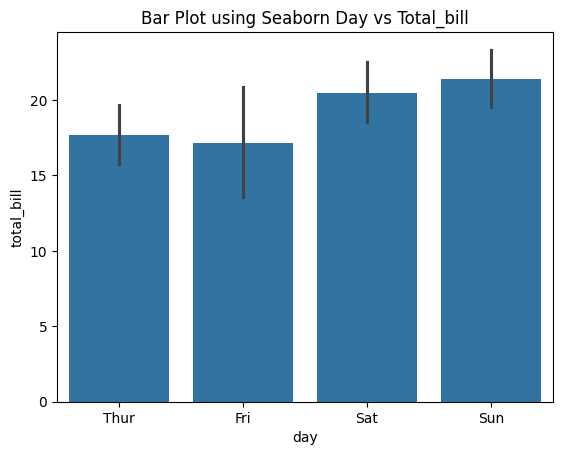

In [ ]:
sns.barplot(x='day', y ='total_bill', data= tips)
plt.title('Bar Plot using Seaborn Day vs Total_bill')
plt.show()

### **Box PLots**

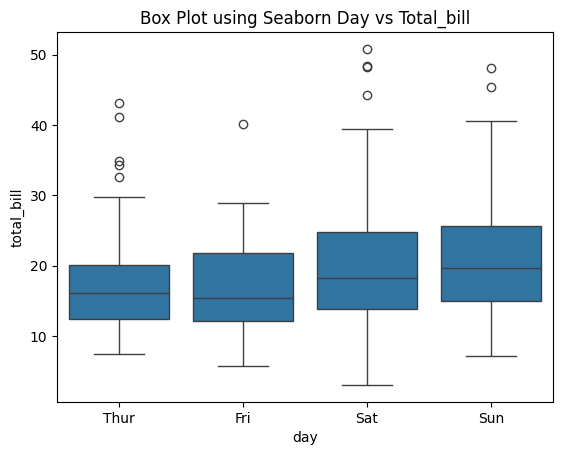

In [ ]:
sns.boxplot(x='day', y='total_bill', data=tips)
plt.title('Box Plot using Seaborn Day vs Total_bill')
plt.show()

## **with mean and median values**

/tmp/ipython-input-150505427.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tips.groupby('day')['total_bill'].agg(['mean', 'median'])


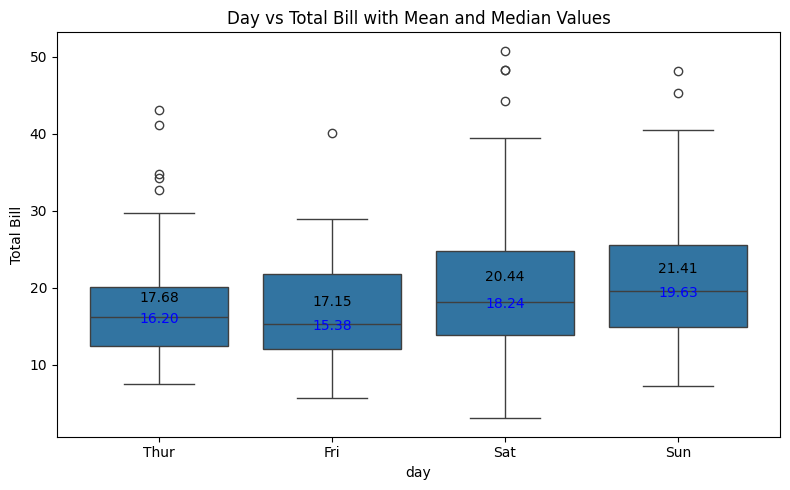

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='day', y='total_bill', data=tips)

stats = tips.groupby('day')['total_bill'].agg(['mean', 'median'])

for i, day in enumerate(stats.index):

    mean_val = stats.loc[day, 'mean']
    median_val = stats.loc[day, 'median']

    # Mean marker + value
    ax.scatter(i, mean_val, color='red', marker='D', s=60)
    ax.text(i, mean_val + 0.5, f"{mean_val:.2f}", color='black', ha='center')

    # Median marker + value
    ax.scatter(i, median_val, color='blue', marker='o', s=60)
    ax.text(i, median_val - 0.8, f"{median_val:.2f}", color='blue', ha='center')

plt.title('Day vs Total Bill with Mean and Median Values')
plt.ylabel('Total Bill')
plt.tight_layout()
plt.show()

### **Violin plot to see the distribution**

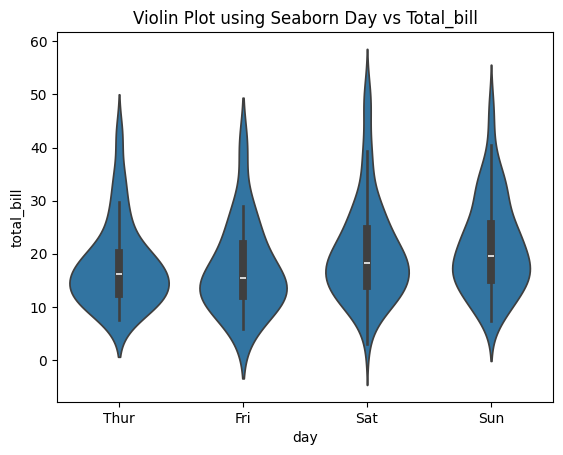

In [ ]:
sns.violinplot(x = 'day', y='total_bill', data=tips)
plt.title('Violin Plot using Seaborn Day vs Total_bill')
plt.show()

### **Histogram**

<Axes: xlabel='total_bill', ylabel='Count'>

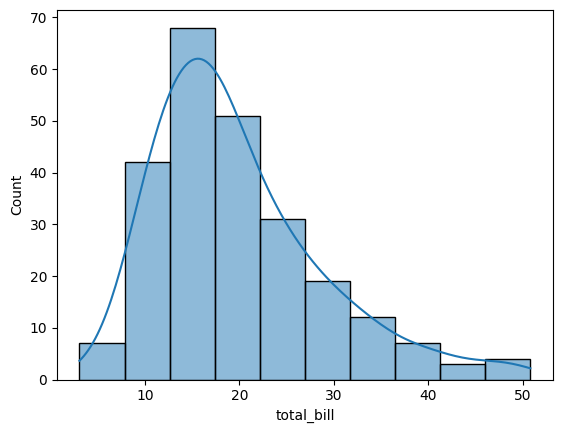

In [ ]:
sns.histplot(tips['total_bill'], bins=10, kde = True)


## **With `Q1`, `Q2`, and `IQR`**

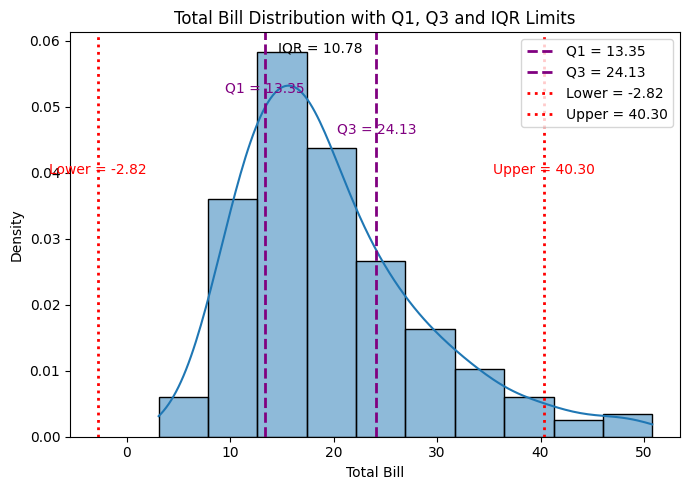

In [ ]:
d = tips['total_bill'].dropna()

Q1 = d.quantile(0.25)
Q3 = d.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

plt.figure(figsize=(7,5))
sns.histplot(d, bins=10, kde=True, stat="density")

# Quartile lines
plt.axvline(Q1, linestyle='--', linewidth=2, color='purple', label=f"Q1 = {Q1:.2f}")
plt.axvline(Q3, linestyle='--', linewidth=2, color='purple', label=f"Q3 = {Q3:.2f}")

# IQR bound lines
plt.axvline(lower, linestyle=':', linewidth=2, color='red', label=f"Lower = {lower:.2f}")
plt.axvline(upper, linestyle=':', linewidth=2, color='red', label=f"Upper = {upper:.2f}")

# Numeric labels
ymax = plt.ylim()[1]
plt.text(Q1, ymax*0.85, f"Q1 = {Q1:.2f}", ha='center', color='purple')
plt.text(Q3, ymax*0.75, f"Q3 = {Q3:.2f}", ha='center', color='purple')
plt.text(lower, ymax*0.65, f"Lower = {lower:.2f}", ha='center', color='red')
plt.text(upper, ymax*0.65, f"Upper = {upper:.2f}", ha='center', color='red')

iqr_val = Q3 - Q1
mid = (Q1 + Q3) / 2
plt.text(mid, ymax*0.95, f"IQR = {iqr_val:.2f}", ha='center', color='black', fontsize=10)

plt.title("Total Bill Distribution with Q1, Q3 and IQR Limits")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# **With `mean`, `median`, and `±2.7σ` values**

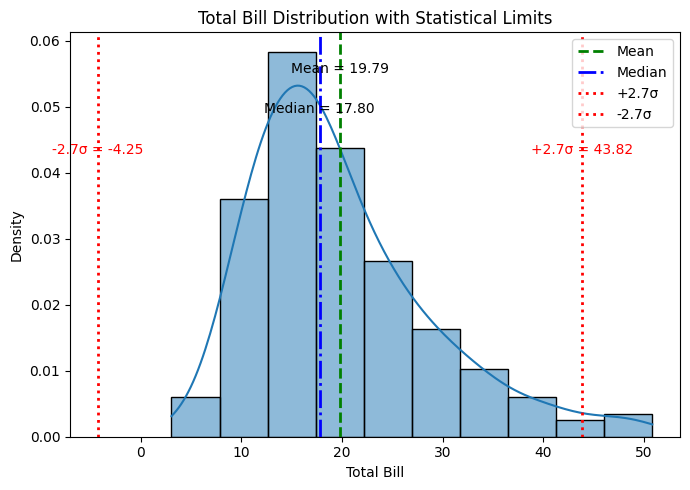

In [ ]:
d = tips['total_bill'].dropna()

mu = d.mean()
median = d.median()
sigma = d.std(ddof=1)

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(7,5))
sns.histplot(d, bins=10, kde=True, stat="density")

# Reference lines
plt.axvline(mu, linestyle='--', linewidth=2, label='Mean', color ='green')
plt.axvline(median, linestyle='-.', linewidth=2, label='Median', color = 'blue')
plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label='+2.7σ')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label='-2.7σ')

# Numeric labels
ymax = plt.ylim()[1]
plt.text(mu, ymax*0.90, f"Mean = {mu:.2f}", ha='center')
plt.text(median, ymax*0.80, f"Median = {median:.2f}", ha='center')
plt.text(ucl, ymax*0.70, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
plt.text(lcl, ymax*0.70, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

plt.title("Total Bill Distribution with Statistical Limits")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### **KDE plots**

/tmp/ipython-input-2116418351.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=tips['total_bill'], shade=True)


<Axes: xlabel='total_bill', ylabel='Density'>

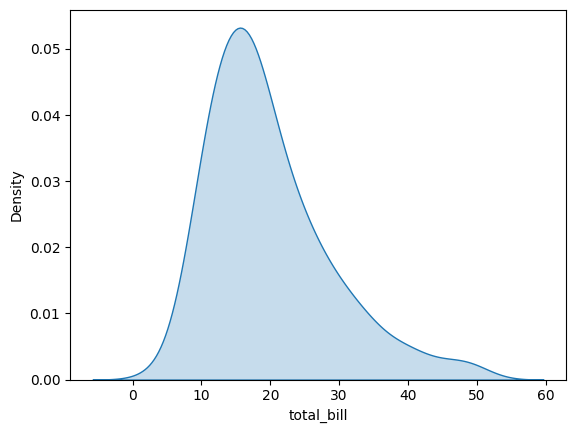

In [ ]:
sns.kdeplot(data=tips['total_bill'], shade=True)

### **Pairplots**

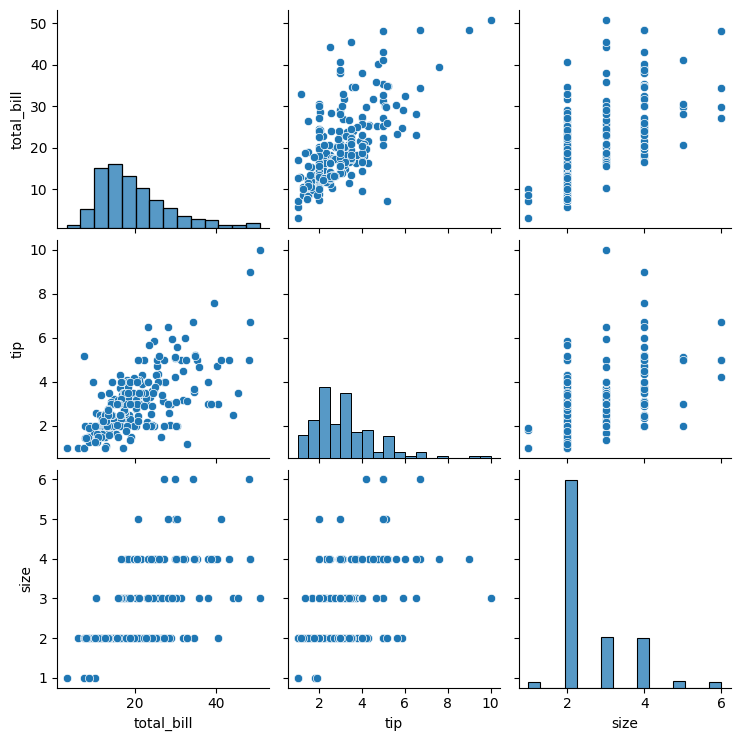

In [ ]:
sns.pairplot(tips)

In [ ]:
sales_df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


[]

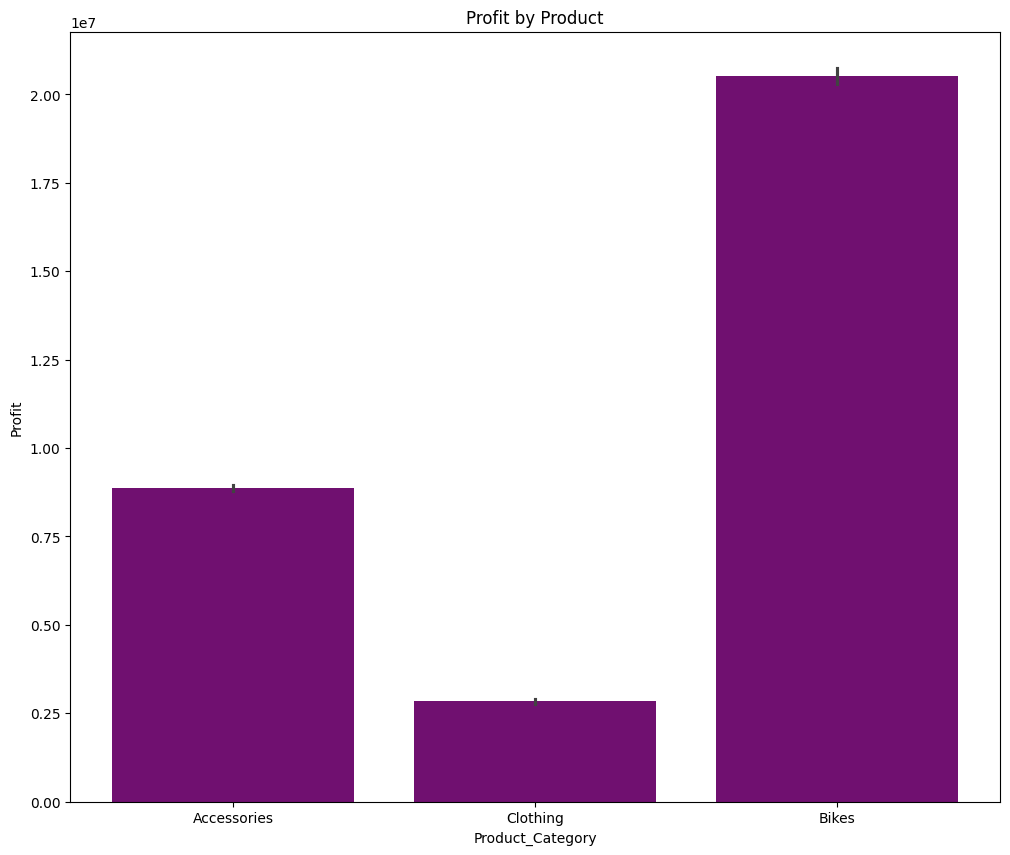

In [ ]:
# Plot Profit by  Product_Category
plt.figure(figsize=(12,10))

sns.barplot(x='Product_Category', y='Profit', color = 'purple', data=sales_df, estimator = sum)
plt.title('Profit by Product')
plt.xlabel('Product_Category')
plt.ylabel('Profit')
plt.plot()